# Problem Statement

## Business Context
The advent of e-news, or electronic news, portals has offered us a great opportunity to quickly get updates on the day-to-day events occurring globally. The information on these portals is retrieved electronically from online databases, processed using a variety of software, and then transmitted to the users. There are multiple advantages of transmitting news electronically, like faster access to the content and the ability to utilize different technologies such as audio, graphics, video, and other interactive elements that are either not being used or aren’t common yet in traditional newspapers.

E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express believe that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to decide to subscribe.

[Companies often analyze user responses to two variants of a product to decide which of the two variants is more effective. This experimental technique, known as A/B testing, is used to determine whether a new feature attracts users based on a chosen metric.]
### Objective
The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team experimented by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected. Being a data scientist in E-news Express, you have been asked to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal by answering the following questions:

Do the users spend more time on the new landing page than on the existing landing page?
Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?
Does the converted status depend on the preferred language?
Is the time spent on the new page the same for the different language users?
### Data Dictionary
The data contains information regarding the interaction of users in both groups with the two versions of the landing page.

* user_id - Unique user ID of the person visiting the website
* group - Whether the user belongs to the first group (control) or the second group (treatment)
* landing_page - Whether the landing page is new or old
* time_spent_on_the_page - Time (in minutes) spent by the user on the landing page
* converted - Whether the user gets converted to a subscriber of the news portal or not
* language_preferred - language chosen by the user to view the landing page

### Importing libraries

In [ ]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# import the required fuction for statistical analysis
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
from scipy.stats import chi2_contingency,levene,f_oneway




### Loading Data

In [ ]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading the dataset
data_org = pd.read_csv("/content/drive/MyDrive/content/drive/Statistics/abtest.csv")

### Data Overview

In [ ]:
data=data_org.copy()

In [ ]:
# view the first 5 rows of the data
data.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [ ]:
# view the last 5 rows of the data
data.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [ ]:
# let's check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


- There are a total of 6 columns and 100 observations in the dataset
- There is no null values
- There are 5 categorical and one continous numerical features
- There are data from 100 users

In [ ]:
# Drop case_id column as it has no significance
data.drop('user_id',axis=1,inplace=True)

##### Check Sample

In [ ]:
data.sample()

,group,landing_page,time_spent_on_the_page,converted,language_preferred
44,treatment,new,3.91,no,English


##### Check Duplicates

In [ ]:
# let's check for duplicate values in the data
data.duplicated().sum()

np.int64(0)

- no duplicate rows in the data

##### Check Missing Values

In [ ]:
# let's check for missing values in the data
round(data.isnull().sum() / data.isnull().count() * 100, 2)

,0
group,0.0
landing_page,0.0
time_spent_on_the_page,0.0
converted,0.0
language_preferred,0.0


- There are no missing values in the `DataSet`

##### Check the number of unique values in each column

In [ ]:
data.nunique()

,0
group,2
landing_page,2
time_spent_on_the_page,94
converted,2
language_preferred,3



- We have only one numerical features, time_spent_on_the_page and the rest are categorical


## Split the Dataset

* Since we have two potetional group Treatment and Control,  we process the data based on group.
- Test was conducted on control and treatment group having equal number of users
- Old and New Landing page was tested with  control and treatment group respectively





In [ ]:
# split into two groups
control_group = pd.DataFrame(data[data['group'] == 'control'])
treatment_group = pd.DataFrame(data[data['group'] == 'treatment'])

print("Control Group Head:")
print(control_group.head())
print("\nTreatment Group Head:")
print(treatment_group.head())

Control Group Head:
     group landing_page  time_spent_on_the_page converted language_preferred
0  control          old                    3.48        no            Spanish
3  control          old                    3.02        no             French
5  control          old                    5.28       yes            English
7  control          old                    6.53       yes            Spanish
9  control          old                    2.08        no            English

Treatment Group Head:
       group landing_page  time_spent_on_the_page converted language_preferred
1  treatment          new                    7.13       yes            English
2  treatment          new                    4.40        no            Spanish
4  treatment          new                    4.75       yes            Spanish
6  treatment          new                    5.25       yes             French
8  treatment          new                   10.71       yes             French


### Statistical Summary

#### Control group

In [ ]:
# let's view the statistical summary of the numerical columns in the data
control_group.describe().T

,count,mean,std,min,25%,50%,75%,max
time_spent_on_the_page,50.0,4.5324,2.581975,0.19,2.72,4.38,6.4425,10.3


- Users spend on an average 4.5 minutes on the website
- The minimum time is 0.19 and Maximum is 10.3 minutes
- Since the median (4.38 min) is slightly lower than the mean (4.5 min), the distribution is mildly right-skewed and more than half of the users actually spend <= 4.5 minutes on the website
- Standard deviation: 2.58 minutes indicates moderate variability in user engagement

#### Treatment group

In [ ]:
# let's view the statistical summary of the numerical columns in the data
treatment_group.describe().T

,count,mean,std,min,25%,50%,75%,max
time_spent_on_the_page,50.0,6.2232,1.817031,1.65,5.175,6.105,7.16,10.71


- Users spent on an average  6.2 minutes on the website
- The minimum time is 1.65 and Maximum is 10.71 minutes
- Since the median (6.1 min) approximately equal mean (6.2 min), the distribution is normally distributed, 50% of users spend less than 6.1 minutes (the median) and 50% spend more than 6.1 minutes
- The treatment appears effective - users spend significantly more time on the page
- Less variability in the treatment group (lower std dev)
- No extremely low values in treatment group (min 1.65 vs 0.19)
- More consistent engagement across users

### Checking the value count for each variables

### Control group

In [ ]:

# Printing number of count of each unique value in each column
for column in control_group.columns:
    print(control_group[column].value_counts())
    print("-" * 40)

group
control    50
Name: count, dtype: int64
----------------------------------------
landing_page
old    50
Name: count, dtype: int64
----------------------------------------
time_spent_on_the_page
0.40     2
6.04     2
5.28     1
3.48     1
2.08     1
6.21     1
2.58     1
3.02     1
8.72     1
10.30    1
3.88     1
2.66     1
7.03     1
4.05     1
4.28     1
6.53     1
3.52     1
5.39     1
4.46     1
4.52     1
8.50     1
3.13     1
0.19     1
8.46     1
1.92     1
8.02     1
0.22     1
4.71     1
0.93     1
1.81     1
7.40     1
9.15     1
4.18     1
5.47     1
5.96     1
6.60     1
4.75     1
2.23     1
4.87     1
6.57     1
1.44     1
3.21     1
2.90     1
4.30     1
0.91     1
8.35     1
3.05     1
6.52     1
Name: count, dtype: int64
----------------------------------------
converted
no     29
yes    21
Name: count, dtype: int64
----------------------------------------
language_preferred
Spanish    17
French     17
English    16
Name: count, dtype: int64
---------------------

- There are 21 customers who converted to subscription and 29 did not.
- Seventeen users preferred languages were Spanish and French. English was chosen by 16 users.

### Treatment group

In [ ]:

# Printing number of count of each unique value in each column
for column in treatment_group.columns:
    print(treatment_group[column].value_counts())
    print("-" * 40)

group
treatment    50
Name: count, dtype: int64
----------------------------------------
landing_page
new    50
Name: count, dtype: int64
----------------------------------------
time_spent_on_the_page
5.86     2
7.16     2
4.75     1
7.13     1
5.25     1
10.71    1
6.03     1
4.40     1
8.73     1
3.65     1
7.02     1
6.18     1
4.39     1
9.49     1
7.81     1
6.27     1
5.41     1
1.65     1
3.91     1
5.37     1
7.23     1
8.08     1
10.50    1
5.65     1
6.47     1
6.41     1
8.30     1
6.01     1
6.79     1
7.27     1
6.70     1
5.42     1
5.08     1
7.46     1
3.88     1
9.12     1
4.68     1
5.26     1
5.74     1
6.71     1
3.68     1
3.30     1
5.40     1
8.47     1
4.94     1
5.15     1
7.07     1
6.20     1
Name: count, dtype: int64
----------------------------------------
converted
yes    33
no     17
Name: count, dtype: int64
----------------------------------------
language_preferred
Spanish    17
French     17
English    16
Name: count, dtype: int64
-------------------

- There are 33 customers who converted to subscription and 17 did not.
- Seventeen users preferred languages were Spanish and French. English was chosen by 16 users.

# EDA

## Univariate analysis

### Control group

#### Convertion rate with respect to the feature `converted`

In [ ]:
print(control_group['converted'].value_counts())

converted
no     29
yes    21
Name: count, dtype: int64


- 21 users converted and 29 users did not

In [ ]:
# Function to plot histogram
def plot_hist(control_group,feature,i):
  plt.subplot(5,3,i+1)
  plt.xticks(rotation=45)
  sns.histplot(control_group,x=feature)


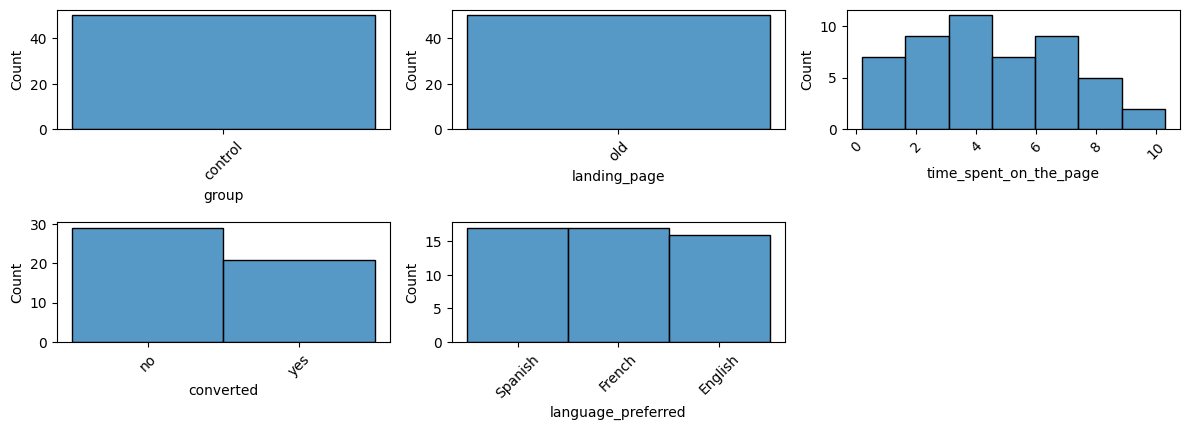

In [ ]:
# Iterate over each numerical features
plt.figure(figsize=(12,10))
for i,feature in enumerate(control_group.columns):
  plot_hist(control_group,feature,i)
plt.tight_layout()


- The number of users in control are 50.
- Time spent on the page by the users is slightly right skewed
- The highest frequency of users falls in the 4–6 minute bin.
- More than half of the users (29 users) did not do the convertion
- Lower Engagement and high variability shows that there is higher tendency for users to leave early.


#### IQR analysis

In [ ]:
# Function to plot box plot
def plot_box(control_group,feature,i):
  # Define subplots
  plt.subplot(5,3,i+1)
  #plot boxplot
  sns.boxplot(control_group,x=feature,showmeans=True)


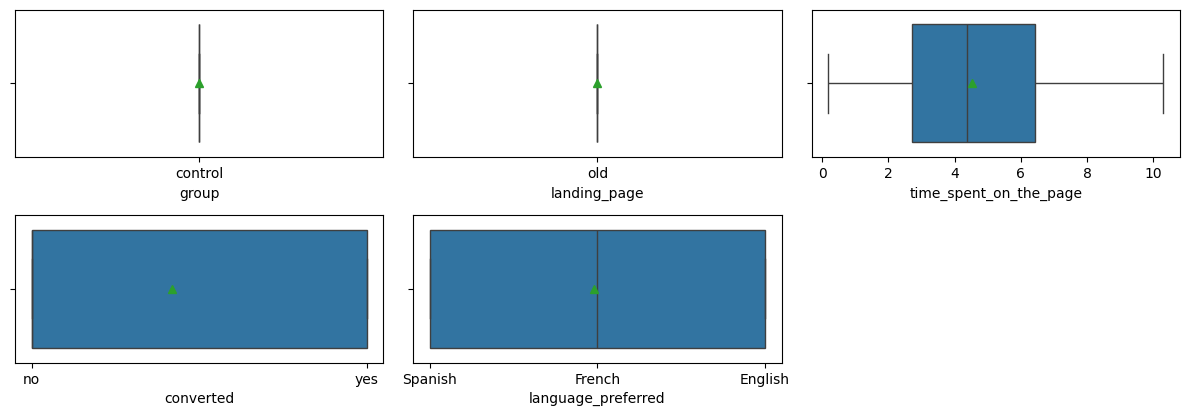

In [ ]:
# Set the figure size
plt.figure(figsize=(12,10))
# Iterate over each numerical features
for i,feature in enumerate(control_group.columns):
  plot_box(control_group,feature,i,)
plt.tight_layout()


- There are no outliers in the observed data.
- Time spent has good variability for analysis
- Conversion rates and language preferences show different central tendencies



## Treatment group

#### Convertion rate with respect to the feature `converted`

In [ ]:
print(treatment_group['converted'].value_counts())

converted
yes    33
no     17
Name: count, dtype: int64


- 33 users converted and 17 users did not
- Effective conversion than Control group

In [ ]:
# Function to plot histogram
def plot_hist(treatment_group_group,feature,i):
  plt.subplot(5,3,i+1)
  plt.xticks(rotation=45)
  sns.histplot(treatment_group,x=feature)


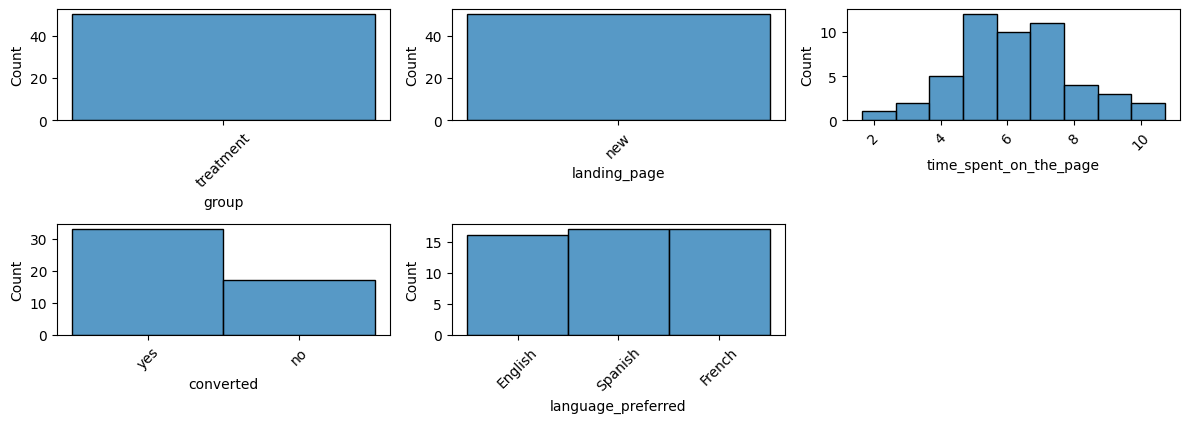

In [ ]:
# Iterate over each numerical features
plt.figure(figsize=(12,10))
for i,feature in enumerate(treatment_group.columns):
  plot_hist(treatment_group,feature,i)
plt.tight_layout()


- The number of users in control are 50.
- Majority of the users spent on average ~6 minutes
- Most users spend between 4-7 minutes on the page
- Distribution of time_spent is normal/symmetric with a slight right skew
- Fewer very short visits compared to control group


#### IQR analysis

In [ ]:
# Function to plot box plot
def plot_box(treatment_group,feature,i):
  # Define subplots
  plt.subplot(5,3,i+1)
  #plot boxplot
  sns.boxplot(treatment_group,x=feature,showmeans=True)


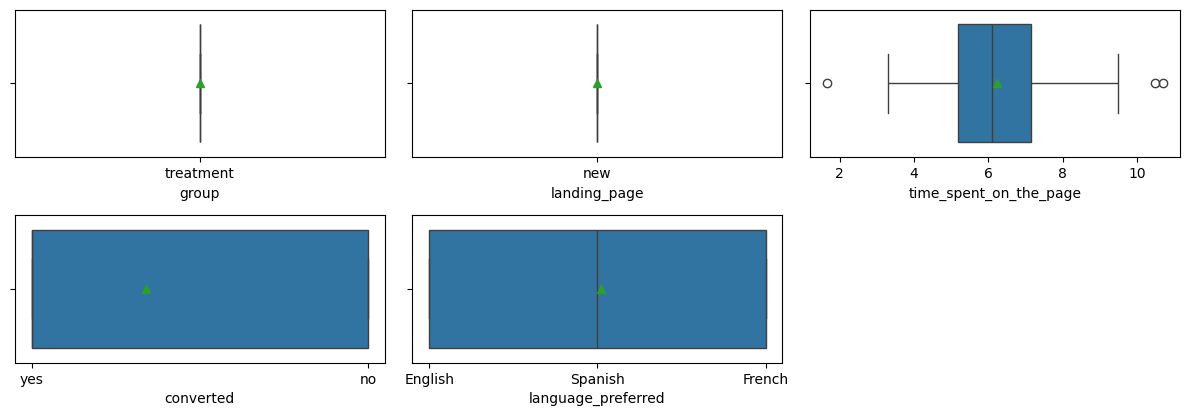

In [ ]:
# Set the figure size
plt.figure(figsize=(12,10))
# Iterate over each numerical features
for i,feature in enumerate(treatment_group.columns):
  plot_box(treatment_group,feature,i,)
plt.tight_layout()


- The outliers in the treatment - time spent can consider as valid observed data.
-Time spent has good variability for analysis
- Conversion rates and language preferences show different central tendencies



# Bivariate Analysis

### Control group

#### Visualize the relationships time_spent Vs converted

[]

<Figure size 1500x1500 with 0 Axes>

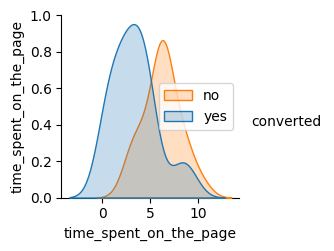

In [ ]:
# Plotting a pairplot
#Set the figure size
plt.figure(figsize=(15,15))
# Plot pairwise graphs
sns.pairplot(control_group,hue='converted')
plt.legend(labels=['no','yes'])
plt.plot()

- Users who converted (blue - "yes") spent less time on the page, with a peak around 5-6 minutes
- Users who did NOT convert (orange - "no") spent more time on the page, with a peak around 7-8 minutes

### Treatment group

#### Visualize the relationships time_spent Vs converted




[]

<Figure size 1500x1500 with 0 Axes>

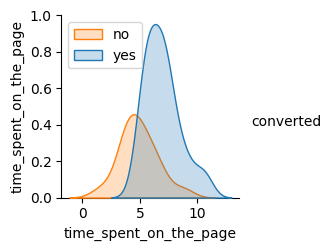

In [ ]:
# Plotting a pairplot
#Set the figure size
plt.figure(figsize=(15,15))
# Plot pairwise graphs
sns.pairplot(treatment_group,hue='converted')
plt.legend(labels=['no','yes'])
plt.plot()

- Users who converted (blue - "yes") spent more time on the page, with a peak around 6-7 minutes
- Users who did NOT convert (orange - "no") spent less time on the page, with a peak around 4-5 minutes

### Average time spent by each group

In [ ]:
# Find average time spent by each group vs converted
average_time_spent = data.groupby(['group', 'converted'])['time_spent_on_the_page'].mean()
display(average_time_spent)

group      converted
control    no           3.349310
           yes          6.166190
treatment  no           4.882353
           yes          6.913939
Name: time_spent_on_the_page, dtype: float64

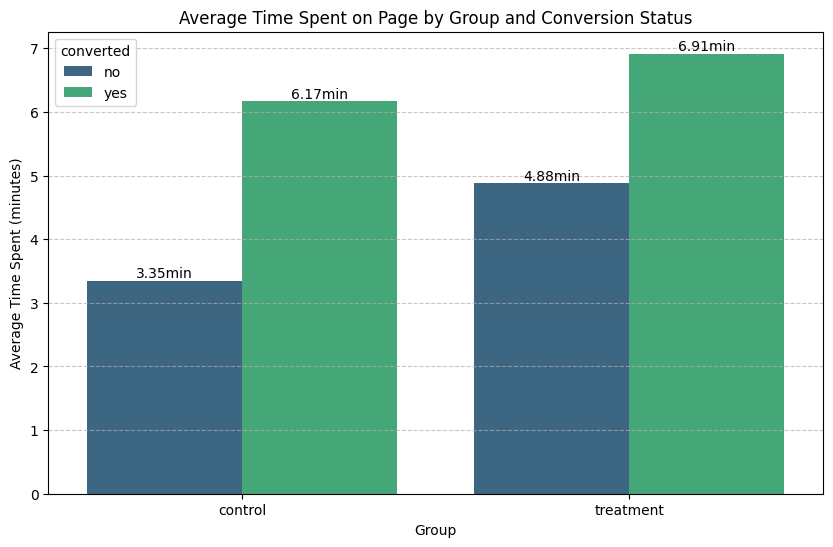

In [ ]:
# Prepare data to plot
plot_data = average_time_spent.reset_index()
# Set the figure size
plt.figure(figsize=(10, 6))
# call plot function
ax = sns.barplot(data=plot_data, x='group', y='time_spent_on_the_page', hue='converted', palette='viridis')
# Set the title and labels
plt.title('Average Time Spent on Page by Group and Conversion Status')
plt.xlabel('Group')
plt.ylabel('Average Time Spent (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="{:.2f}min")
# Display the plot
plt.show()

- The converted group in Treatment group spent on an average 6.9 minutes
- The converted group in Control group spent on an average 6.2 minutes
- Non converted group in Control group spent less than non converted group in Treatment group.

### Distribution of Time Spent on the landing apge by Group

[]

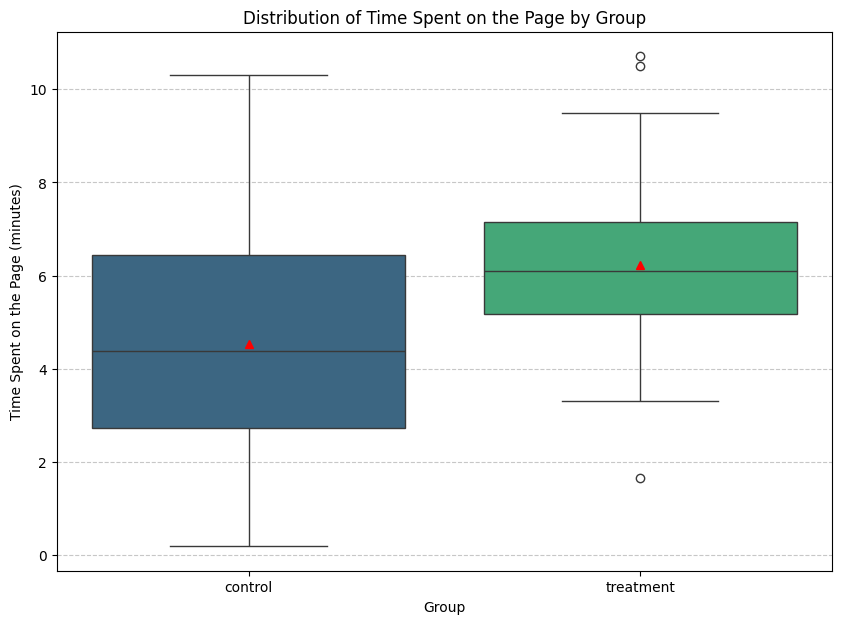

In [ ]:
# Set the figure size
plt.figure(figsize=(10, 7))
# Call the boxplot function
sns.boxplot(x='group', y='time_spent_on_the_page', data=data, showmeans=True, palette='viridis', hue='group', legend=False, meanprops={"markerfacecolor":"red", "markeredgecolor":"red"})
# Set the title and labels
plt.title('Distribution of Time Spent on the Page by Group')
plt.xlabel('Group')
plt.ylabel('Time Spent on the Page (minutes)')
# Set the grid
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Plot the chart
plt.plot()

- Treatment Group Spends More Time: On average, users in the treatment group (new landing page) spent more time on the page. Their median time is noticeably higher than that of the control group.
- Higher Median and Upper Quartile in Treatment Group: The box for the treatment group is positioned higher on the y-axis, indicating that both their median and upper quartile values for time spent are greater than those in the control group.
- Less Variability in Treatment Group: The box for the treatment group appears slightly narrower, suggesting less variability (a smaller interquartile range) in the time spent compared to the control group.
- Similar Minimums, Higher Maximum in Treatment: Both groups have some users spending very little time, but the maximum time spent is higher in the treatment group.
- The outliers in the Treatment group are valid data
- The new landing page (treatment group) appears to be more engaging, with users spending more time on it and a more consistent distribution of engagement times, compared to the old landing page (control group)

### Average time spent by different language speakers

In [ ]:
# Calculate average time spent by different langauage speakers
average_time_spent = data.groupby(['group', 'language_preferred'])['time_spent_on_the_page'].mean()
average_time_spent

group      language_preferred
control    English               4.454375
           French                4.310000
           Spanish               4.828235
treatment  English               6.663750
           French                6.196471
           Spanish               5.835294
Name: time_spent_on_the_page, dtype: float64

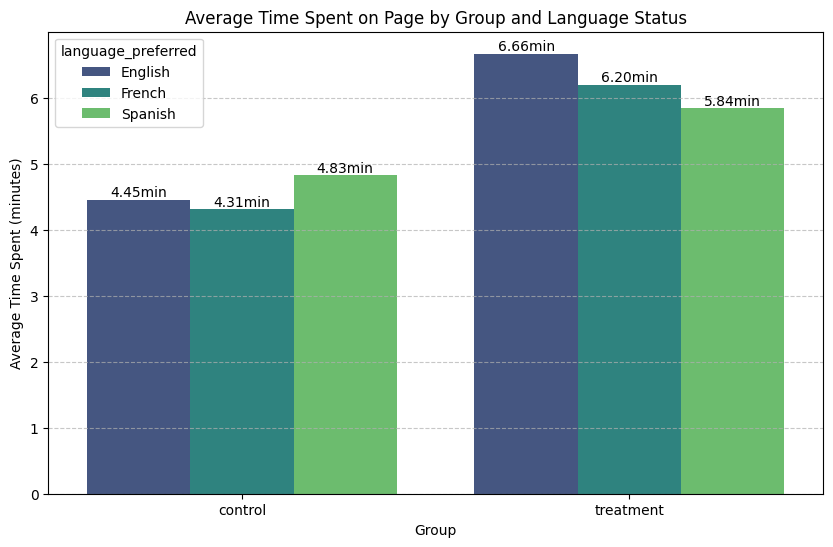

In [ ]:
# Prepare the data to plot
plot_data = average_time_spent.reset_index()
# set the fugure size
plt.figure(figsize=(10, 6))
# Call the barplot function
ax = sns.barplot(data=plot_data, x='group', y='time_spent_on_the_page', hue='language_preferred', palette='viridis')
# Set the title and labels
plt.title('Average Time Spent on Page by Group and Language Status')
plt.xlabel('Group')
plt.ylabel('Average Time Spent (minutes)')
# Set the grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="{:.2f}min")
# Plot the chart
plt.show()

- English speakers spend on an average 6.66 minutes in the treatment group and 4.83 minutes in the control group
- French speakers spent on an average the lowest (4.31) minutes in the control group
- Spanish speakers spent on an average the lowest (5.84) minutes in the treatmant group

### Distribution of Time Spent on Page by Language, Group, and Conversion Status

In [ ]:
# Calculate the average time by Language, Group and conversion status
average_time_spent = data.groupby(['group', 'converted','language_preferred'])['time_spent_on_the_page'].mean()
average_time_spent

group      converted  language_preferred
control    no         English               1.776000
                      French                3.669286
                      Spanish               3.688000
           yes        English               5.671818
                      French                7.300000
                      Spanish               6.457143
treatment  no         English               5.506667
                      French                4.400000
                      Spanish               4.660000
           yes        English               7.358000
                      French                6.945000
                      Spanish               6.476364
Name: time_spent_on_the_page, dtype: float64

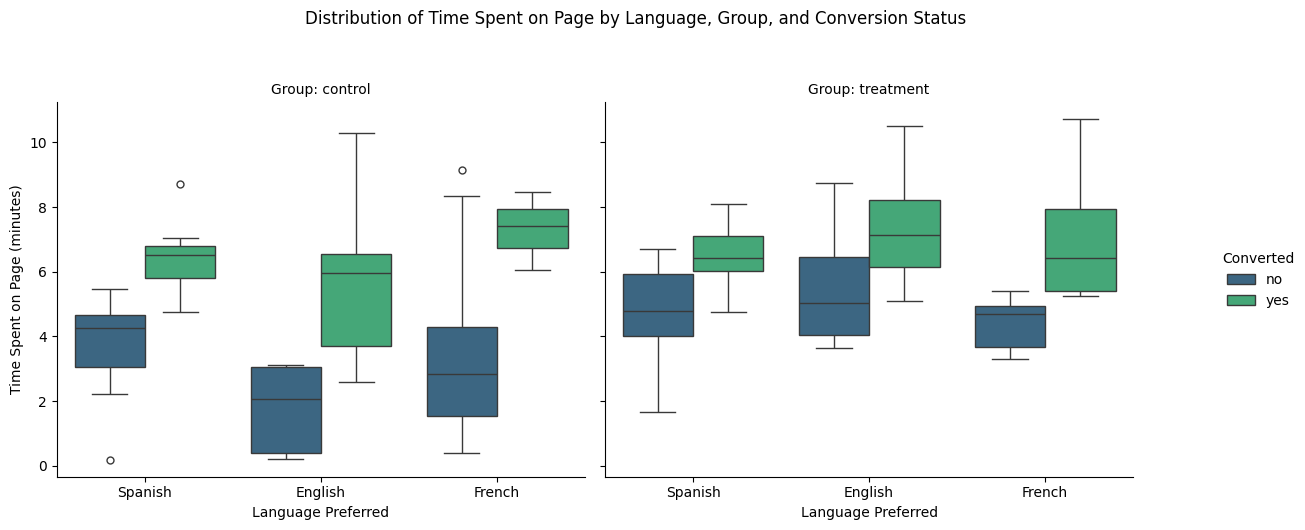

In [ ]:

# Create the boxplot
g = sns.catplot(
    data=data,
    x='language_preferred',
    y='time_spent_on_the_page',
    col='group',
    hue='converted',
    kind='box',
    height=5,
    aspect=1.2,
    palette='viridis',
    col_order=['control', 'treatment']
)

# Set titles and labels
g.set_axis_labels('Language Preferred', 'Time Spent on Page (minutes)')
g.set_titles('Group: {col_name}')
g.fig.suptitle(
    'Distribution of Time Spent on Page by Language, Group, and Conversion Status',
    y=1.05
)

# Reposition the existing legend instead of adding a new one
if g._legend is not None:
    g._legend.set_bbox_to_anchor((1.02, 0.5))
    g._legend.set_title('Converted')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

- Users who convert spend significantly more time on the page (medians around 6–8 minutes) compared to those who don't (medians around 2–5 minutes). This confirms that deeper engagement drives conversions.
- The new landing page (Treatment) is effective, It successfully keeps users engaged for longer, even if they ultimately don't convert. This is a positive sign for future marketing.
-There are outliers in the Control group (e.g., Spanish "no", French "no"), indicating some users left almost immediately (near 0 minutes). These outliers are absent in the Treatment group, suggesting the new page reduces bounce rate
- The Treatment (New Page) is successful because:
  * It maintains high engagement for users who convert.
  * It significantly boosts engagement for users who don't convert (especially English speakers), keeping them on the site longer than the old page did.


## Hypothesis Testing

### Do the users spend more time on the new landing page than the old landing page?

### Step 1: Define null and alternative hypotheses

The null and alternative hypotheses can be formulated as:

> $H_0:$ The mean usage time on the new landing page is less than or equal to the  mean usage time on the old landing page <br>
> $H_a:$ The mean usage time on the new landing page is greater than  mean usage time on the old landing page

Let $\mu$ be the mean usage time on the landing page by the users <br>
$\mu_{new}$ : mean usage time on the new landing page <br>
$\mu_{old}$ : mean usage time on the old landing page

Mathematically, the above formulated hypotheses can be written as:

>$H_0: \mu_{new} <= \mu_{old} $ <br>
$H_a: \mu_{new} >\mu_{old} $


### Step 2: Select Appropriate test

This is a case of a one-tailed(right- tailed) test for the significance of a single mean. As the population standard deviation is unknown, For comparing the mean usage time between two independent groups (new landing page vs. old landing page), the appropriate statistical test is two-sample t-test.

**Two sample t-test**

- Comparing means of two independent groups
- Continuous outcome variable (time spent)
- One-tailed hypothesis (testing if new > old)
- Sample sizes appear adequate (n=50 per group)<br>
We are provided that the sample is randomly selected and we assume that it has come from a normally distributed population.

### Step 3: Decide the significance level

As given in the problem statement, we select $\alpha = 0.05$.

### Step 4: Preparing Data for Test
####  Find Mean and Std of each group

In [ ]:
# find the sample means and sample standard deviations for the two samples
print('The mean usage time of control group is ' + str(control_group['time_spent_on_the_page'].mean()))
print('The mean usage time of treatment is ' + str(treatment_group['time_spent_on_the_page'].mean()))
print('The standard deviation of usage time of control group is ' + str(round(control_group['time_spent_on_the_page'].std(),2)))
print('The standard deviation of usage time of treatment is ' + str(round(treatment_group['time_spent_on_the_page'].std(),2)))

The mean usage time of control group is 4.532400000000001
The mean usage time of treatment is 6.2232
The standard deviation of usage time of control group is 2.58
The standard deviation of usage time of treatment is 1.82


#### Prepare Data


In [ ]:
# Extract the time spent data for both groups
treatment_time = treatment_group['time_spent_on_the_page']
control_time = control_group['time_spent_on_the_page']


#### Visualize Data

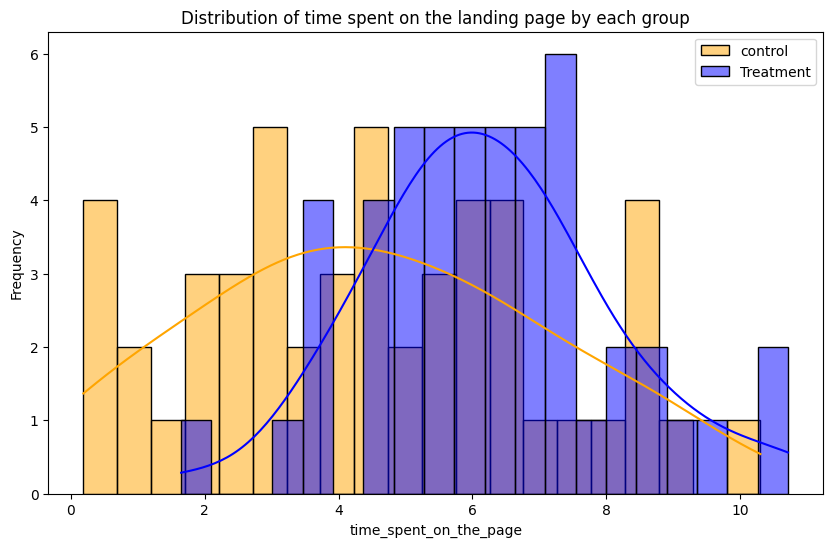

In [ ]:
#plot the histogram distribution of each group spending time
plt.figure(figsize=(10, 6))
sns.histplot(control_group['time_spent_on_the_page'], bins=20, kde=True, color='orange', label='control')
sns.histplot(treatment_group['time_spent_on_the_page'], bins=20, kde=True, color='blue', label='Treatment')
plt.title('Distribution of time spent on the landing page by each group')
plt.xlabel('time_spent_on_the_page')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Step 5: Calculate the p-value

- We will use the `ttest_ind()` function from the `scipy.stats` library to perform a two-sample t-test.
- The `ttest_ind()` function takes the sample observations, hypothesized population mean and the direction of the alternative hypothesis as input and returns the test statistic and the p-value for the test.
    - The sample observations are the values of usage time on the landing page in the dataset.
    - The sample variances of old and new landing apges are not equal , thus `equal_var='false'`
    - As it is a one-tailed (right) test, we will set the argument `alternative = 'greater'`
    

In [ ]:
# Does NOT assume equal variances
t_stat, p_value_right_tailed = stats.ttest_ind(
    treatment_time,
    control_time,
    equal_var=False,
    alternative='greater'
)
# Check direction of t-statistic for right-tailed test
if t_stat > 0:
    print("T-statistic is positive (treatment mean > control mean)")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value (right-tailed): {p_value_right_tailed:.4f}")
else:
    print("T-statistic is negative (treatment mean < control mean)")
    print("Cannot reject null hypothesis for right-tailed test")




T-statistic is positive (treatment mean > control mean)
T-statistic: 3.7868
P-value (right-tailed): 0.0001


### Step 6: Compare the p-value with $\alpha$

In [ ]:
# print the conclusion based on p-value
# Decision at α = 0.05
alpha = 0.05

print("Hypothesis Test Results")
print(f"Significance Level (α): {alpha}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (right-tailed): {p_value_right_tailed:.4f}")

if p_value_right_tailed < alpha:
    print(f"\nREJECT H₀ (p-value {p_value_right_tailed:.4f} < {alpha})")
    print("Conclusion: Users spend SIGNIFICANTLY MORE time on the new landing page")
else:
    print(f"\nFAIL TO REJECT H₀ (p-value {p_value_right_tailed:.4f} ≥ {alpha})")
    print("Conclusion: No significant evidence that new landing page increases time spent")


Hypothesis Test Results
Significance Level (α): 0.05
T-statistic: 3.7868
P-value (right-tailed): 0.0001

REJECT H₀ (p-value 0.0001 < 0.05)
Conclusion: Users spend SIGNIFICANTLY MORE time on the new landing page


### Step 7: Draw Inference

At a 5% significance level, we reject the null hypothesis. Hence, we have enough statistical evidence to say that ***the users spend more mean usage time on new landing page than the old landing page***.

## Hypothesis Testing

### Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

### Step 1: Define null and alternative hypotheses

<br>
The null and alternative hypotheses can be formulated as:<br>

> $H_0:$ The conversion rate for the new page is less than or equal to the conversion rate for the old page <br>
> $H_a:$ The conversion rate for the new page is greater than the conversion rate for the old page
<br>
$P_{new}$ : proportion of conversions on new landing page<br>
$P_{old}$ : proportion of conversions on old landing page <br><br>
Mathematically, the above formulated hypotheses can be written as:

>$H_0: P_{new} <= P_{old} $ <br>
$H_a: P_{new} >P_{old} $


### Step 2: Select Appropriate test

For comparing conversion rates (proportions) between two groups, the appropriate statistical test is: Two-Proportion Z-Test. <br>
This test is used for <br>
- Comparing proportions (conversion rates) between two independent groups
- Binary outcome (converted: yes/no)
- Large sample sizes (n ≥ 30 per group)
- Independent samples


### Step 3: Decide the significance level

As given in the problem statement, we select $\alpha = 0.05$.

### Step 4 : Prepare Data for Test



##### Calculate the Proportions

In [ ]:

# Extract the time spent data for both groups
treatment_time = treatment_group['time_spent_on_the_page']
control_time = control_group['time_spent_on_the_page']

# Calculate conversion counts
# Count conversions (yes) in each group
treatment_conversions = treatment_group[treatment_group['converted'] == 'yes'].shape[0]
control_conversions = control_group[control_group['converted'] == 'yes'].shape[0]

# Total sample sizes
treatment_n = len(treatment_group)
control_n = len(control_group)

# Calculate conversion rates
treatment_rate = treatment_conversions / treatment_n
control_rate = control_conversions / control_n


print("Conversion rate summary")
print(f"Treatment Group (New Page):")
print(f"  Conversions: {treatment_conversions} / {treatment_n}")
print(f"  Conversion Rate: {treatment_rate:.4f} ({treatment_rate*100:.2f}%)")
print(f"\nControl Group (Old Page):")
print(f"  Conversions: {control_conversions} / {control_n}")
print(f"  Conversion Rate: {control_rate:.4f} ({control_rate*100:.2f}%)")
print(f"\nDifference: {treatment_rate - control_rate:.4f} ({(treatment_rate - control_rate)*100:.2f}%)")


Conversion rate summary
Treatment Group (New Page):
  Conversions: 33 / 50
  Conversion Rate: 0.6600 (66.00%)

Control Group (Old Page):
  Conversions: 21 / 50
  Conversion Rate: 0.4200 (42.00%)

Difference: 0.2400 (24.00%)


#### Visualize the data

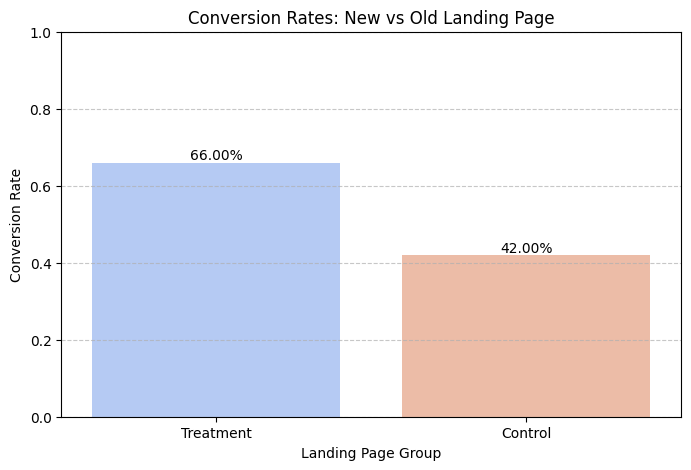

In [ ]:
# Create a DataFrame for plotting
conversion_data = pd.DataFrame({
    'Group': ['Treatment', 'Control'],
    'Conversion Rate': [treatment_rate, control_rate]
})

# Set the figure size
plt.figure(figsize=(8, 5))

# Create the bar plot
ax = sns.barplot(x='Group', y='Conversion Rate', hue='Group', data=conversion_data, palette='coolwarm', legend=False)

# Add title and labels
plt.title('Conversion Rates: New vs Old Landing Page')
plt.xlabel('Landing Page Group')
plt.ylabel('Conversion Rate')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for rates

# Add percentages on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:.2%}')

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Prepare Data

In [ ]:
# Combine counts and n for the test
count = np.array([treatment_conversions, control_conversions])
nobs = np.array([treatment_n, control_n])


### Step 5: Calculate the p-value

- We will use the `proportions_ztest()` function from the `scipy.stats` library to perform a two-proportion Z-test.
- The `proportions_ztest()` function takes the sample observations, hypothesized population mean and the direction of the alternative hypothesis as input and returns the test statistic and the p-value for the test.
    - The sample observations are the values of usage time on the landing page in the dataset.
    - As it is a one-tailed (right) test, we will set the argument `alternative = 'larger'`

In [ ]:
# Two-Proportion Z-Test
# Perform Z-test (right-tailed: 'larger')
z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative='larger'
)

print("Two- Proportion Z-test Results")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (right-tailed): {p_value:.6f}")

Two- Proportion Z-test Results
Z-statistic: 2.4077
P-value (right-tailed): 0.008026


### Step 6: Compare the p-value with $\alpha$

In [ ]:
# Hypothesis Test Decision
alpha = 0.05

print(f"\nSignificance Level (α): {alpha}")
print("\nH₀: p_new ≤ p_old")
print("Hₐ: p_new > p_old")

if p_value < alpha:
    print("Reject H₀")
    print(f"  P-value ({p_value:.6f}) < α ({alpha})")
    print("\nCONCLUSION: The new landing page has a SIGNIFICANTLY HIGHER conversion rate than the old landing page")
else:
    print(f"\n Fail to reject H₀")
    print(f"  P-value ({p_value:.6f}) ≥ α ({alpha})")
    print("\nCONCLUSION: No significant evidence that the new landing page has a higher conversion rate")





Significance Level (α): 0.05

H₀: p_new ≤ p_old
Hₐ: p_new > p_old

 Fail to reject H₀
  P-value (0.432041) ≥ α (0.05)

CONCLUSION: No significant evidence that the new landing page has a higher conversion rate


### Step 7: Draw Inference

At a 5% significance level, we fail to reject the null hypothesis. Hence, we have not enough statistical evidence to say that the ***new landing page has higher conversion rate than the old landing page***. Further data collection or analysis may be needed to reduce uncertainty."

## Hypothesis Testing

### Does the converted status depend on the preferred language?

### Step 1: Define null and alternative hypotheses

<br>
The null and alternative hypotheses can be formulated as:<br>

> $H_0:$  Conversion status and preferred language are independent (no association) <br>
> $H_a:$ Conversion status and preferred language are dependent (associated)
<br>
Mathematically, the above formulated hypotheses can be written as:

>$H_0:P(converted∣language)=P(converted)$ ∀ $ languages $<br>
$H_a: P(converted∣language)=P(converted) $ for at least one language


### Step 2: Select Appropriate test

To test whether conversion status (binary: yes/no) depends on preferred language (categorical: Spanish/French/English), we will use test for independence between two categorical variables, the Chi-Square Test of Independence,<br>
This test is used if

- Both variables are categorical (converted: yes/no; language: Spanish/French/English)
- Testing for association/dependence between variables
- Sample size is adequate (expected cell counts ≥ 5)

### Step 3: Decide the significance level

As given in the problem statement, we select $\alpha = 0.05$.

### Step 4: Prepare Data for Test

In [ ]:
# Create Contingency Table
contingency_table = pd.crosstab(
    data['language_preferred'],  # Rows
    data['converted'],           # Columns
    margins=True               # Add totals
)

print("="*60)
print("CONTINGENCY TABLE: Language vs Conversion")
print("="*60)
print(contingency_table)
print("="*60)


CONTINGENCY TABLE: Language vs Conversion
converted           no  yes  All
language_preferred              
English             11   21   32
French              19   15   34
Spanish             16   18   34
All                 46   54  100


#### Visualize Data

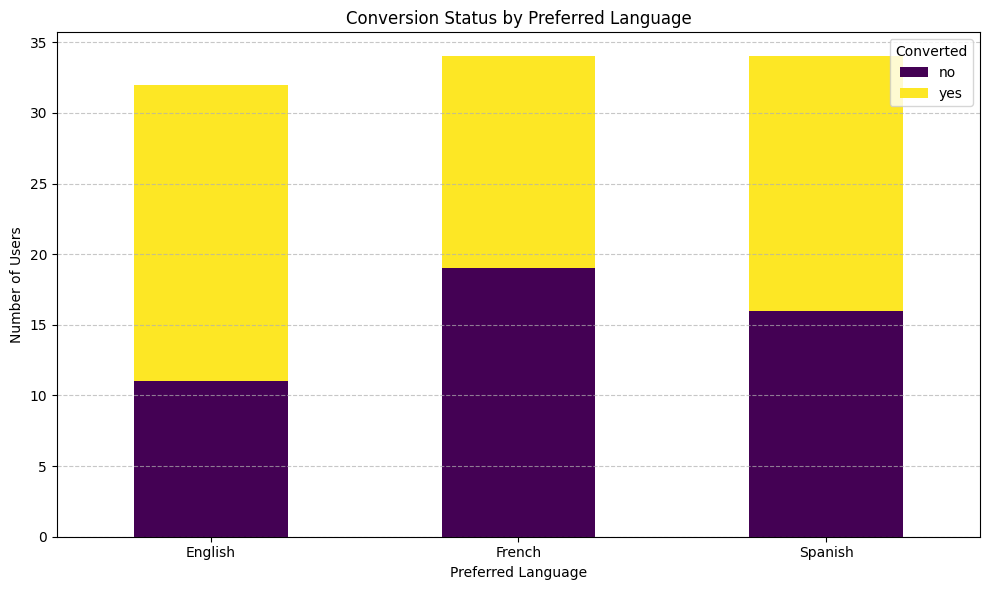

In [ ]:
# Prepare data for plotting (excluding totals 'All')
plot_data = contingency_table.iloc[:-1, :-1]

# Create a stacked bar chart
plot_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

# Set title and labels
plt.title('Conversion Status by Preferred Language')
plt.xlabel('Preferred Language')
plt.ylabel('Number of Users')
# xLabels to horizontal
plt.xticks(rotation=0)
plt.legend(title='Converted')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Step 5: Calculate the p-value

- We will use the `chi2_contigency()` function from the `scipy.stats` library to perform independence test.
- The `chi2_contigency()` function takes the contingency table of observed frequencies (rows × columns)
- The function returns four values:
  - chi2_stat - Chi-square test statistic
  - p_value - P-value for the test
  - dof - Degrees of freedom = (rows - 1) × (columns - 1)
  - expected - Expected frequencies under independence

In [ ]:
# Chi-Square Test of Independence
# Extract the table without margins for the test
observed = pd.crosstab(data['language_preferred'], data['converted'])
chi2_stat, p_value, dof, expected = chi2_contingency(observed)
print("CHI-SQUARE TEST RESULTS")
print(f"Chi-Square Statistic: {chi2_stat:.3f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.3f}")


CHI-SQUARE TEST RESULTS
Chi-Square Statistic: 3.093
Degrees of Freedom: 2
P-value: 0.213


### Step 6: Compare the p-value with $\alpha$

In [ ]:
# Hypothesis Test Decision
alpha = 0.05

print(f"\nSignificance Level (α): {alpha}")

if p_value < alpha:
    print("\nREJECT H₀")
    print(f" P-value ({p_value:.3f}) < α ({alpha})")
    print("\nCONCLUSION: Conversion status SIGNIFICANTLY DEPENDS on preferred language")
else:
    print("\nFAIL TO REJECT H₀")
    print(f"  P-value ({p_value:.3f}) ≥ α ({alpha})")
    print("\nCONCLUSION: No significant evidence that conversion status depends on preferred language")



Significance Level (α): 0.05

FAIL TO REJECT H₀
  P-value (0.432) ≥ α (0.05)

CONCLUSION: No significant evidence that conversion status depends on preferred language


### Step 7: Draw Inference

At a 5% significance level, we fail to reject the null hypothesis. Hence, we have no statistical evidence to say that Conversion status and preferred language are dependent (associated).

## Hypothesis Testing

### Is the mean time spent on the new page same for the different language users?

### Step 1: Define null and alternative hypotheses

<br>
The null and alternative hypotheses can be formulated as:<br>

> $H_0:$  The mean time spent on the new page is the same for all language groups <br>
> $H_a:$ At least one language group has a different mean time spent on the new page
<br>
Mathematically, the above formulated hypotheses can be written as:<br><br>
$ \mu_{spanish}$ = mean time for Spanish speakers <br>
$\mu_{french} $ = mean time for French speakers <br>
$\mu_{english} $ = mean time for English speakers<br>
> $H_0$: $\mu_{spanish}$ = $\mu_{french}$=$\mu_{english}$<br>
> $H_a$: Atleast one $\mu$ is different


### Step 2: Select Appropriate test

The appropriate statistical test to test whether the mean time spent on the new page is the same across different language groups (Spanish, French, English) is One- Way ANOVA<br>
This test is used if

- Comparing means across 3+ independent groups (Spanish, French, English)
- Continuous outcome variable (time spent on page)
- Testing if at least one group mean differs from the others

### Step 3: Decide the significance level

As given in the problem statement, we select $\alpha = 0.05$.

### Step 4: Prepare Data for Test

#### Visualize data

language_preferred
English    6.663750
French     6.196471
Spanish    5.835294
Name: time_spent_on_the_page, dtype: float64


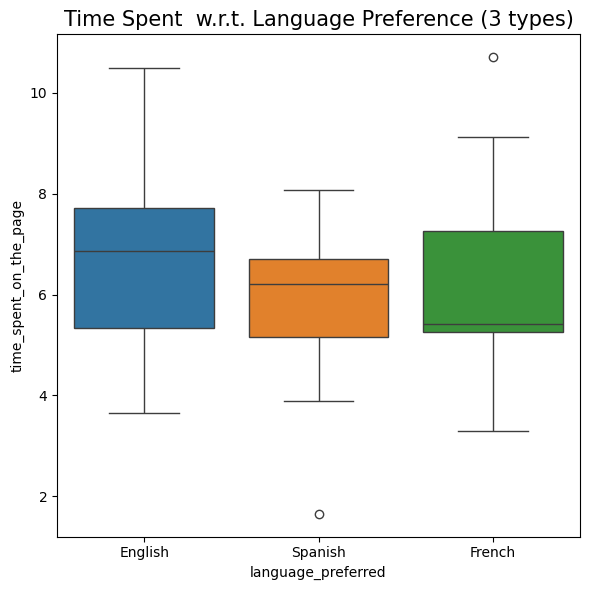

In [ ]:
# mean of carbon emission at different levels of the time_spent_on_the_page factor
print(treatment_group.groupby("language_preferred")["time_spent_on_the_page"].mean())

# draw the boxplot for visualization
fig, ax = plt.subplots(figsize = (6,6))
a = sns.boxplot(x= "language_preferred", y = 'time_spent_on_the_page' , data = treatment_group,hue='language_preferred')
a.set_title("Time Spent  w.r.t. Language Preference (3 types)", fontsize=15)
plt.tight_layout()
plt.show()

Now, the normality and equality of variance assumptions need to be checked.

* For testing of normality, Shapiro-Wilk’s test is applied to the response variable.

* For equality of variance, Levene test is applied to the response variable.

### Shapiro-Wilk’s test

We will test the null hypothesis

>$H_0:$ Time spent on new landing page follows a normal distribution against the alternative hypothesis

>$H_a:$ Time spent on new landing page does not follow a normal distribution

The [`shapiro()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html) function of Scipy will be used to compute the test statistic and p-value.

In [ ]:
# Assumption 1: Normality
# find the p-value
w, p_value = stats.shapiro(treatment_group['time_spent_on_the_page'])
print('The p-value is', p_value)

The p-value is 0.8040040364746845


Since p-value of the test is large, we fail to reject the null hypothesis that the response follows the normal distribution.

### Levene’s test

We will test the null hypothesis

>$H_0$: All the population variances are equal

against the alternative hypothesis

>$H_a$: At least one variance is different from the rest

The [`levene()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html) function of Scipy will be used to compute the test statistic and p-value.

In [ ]:
#Assumption 2: Homogeneity of Variance
statistic, p_value = levene( treatment_group['time_spent_on_the_page'][treatment_group['language_preferred']=="Spanish"],
                                   treatment_group['time_spent_on_the_page'][treatment_group['language_preferred']=="English"],
                                   treatment_group['time_spent_on_the_page'][treatment_group['language_preferred']=="French"])
# find the p-value
print('The p-value is', p_value)

The p-value is 0.46711357711340173


Since the p-value is large, we fail to reject the null hypothesis of homogeneity of variances.

### Let's test whether the assumptions are satisfied or not

* The populations are normally distributed - Yes, the normality assumption is verified using the Shapiro-Wilk’s test.
* Samples are independent simple random samples - Yes, we are informed that the collected sample is a simple random sample.
* Population variances are equal - Yes, the homogeneity of variance assumption is verified using the Levene's test.



### Step 5: Calculate the p-value

The [`f_oneway()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html) function of Scipy will be used to compute the test statistic and p-value.

In [ ]:
# perform one-way anova test
test_stat, p_value = f_oneway(treatment_group.loc[treatment_group['language_preferred'] == 'English', 'time_spent_on_the_page'],
                              treatment_group.loc[treatment_group['language_preferred'] == 'Spanish', 'time_spent_on_the_page'],
                              treatment_group.loc[treatment_group['language_preferred'] == 'French', 'time_spent_on_the_page'])
print('The p-value is ' + str(p_value))

The p-value is 0.43204138694325955


### Insight
As the p-value is greater than the significance level, we fail to reject the null hypothesis. Hence, we do have not enough statistical significance to conclude that at least  one language group has a different mean time spent on the new page.



### Step 6: Compare the p-value with $\alpha$

In [ ]:
# Hypothesis Test Decision
alpha = 0.05

print(f"\nSignificance Level (α): {alpha}")
if p_value < alpha:
    print(f"\n REJECT H₀(p-value {p_value:.3f} < {alpha})")
    print("CONCLUSION: Mean time spent DIFFERS significantly across at least one language group")
else:
    print(f"\n FAIL TO REJECT H₀ (p-value {p_value:.3f} ≥ {alpha})")
    print("CONCLUSION: No significant difference in mean time spent on the new landing page across language groups")



Significance Level (α): 0.05

 FAIL TO REJECT H₀ (p-value 0.432 ≥ 0.05)
CONCLUSION: No significant difference in mean time spent on the new landing page across language groups


### Step 7: Draw Inference

At a 5% significance level, we fail to reject the null hypothesis. Hence, ***we have not enough statistical evidence to say that mean time spent DIFFERS significantly across at least one language group***.

## Conclusions

**Engagement & Time Spent**

- Users spend significantly more time on the new landing page, indicating stronger initial engagement.
- The new design reduces early drop-offs, with fewer users leaving within the first 2 minutes compared to the old page.
- Engagement time on the new page is consistent across English, French, and Spanish speakers, suggesting broad usability.

**Conversion Performance**

- While the new page showed higher observed conversion rate, the difference was not statistically significant at α = 0.05.
- Users who converted on the new page tended to do so more quickly, suggesting a clearer or more compelling value proposition.
- Conversion rates did not vary significantly by preferred language.

**Design & Localization**

- The new landing page delivers a consistent user experience regardless of language preference, reducing the need for immediate locale-specific redesigns.
- Time-to-conversion patterns suggest the new page helps decisive users act faster without confusing hesitant users.

**Business Recommendations**

- Launch the new landing page to all users, as it significantly improves engagement—a leading indicator of conversion potential.
- Continue monitoring conversion metrics post-launch, as the observed uplift may become statistically significant with more traffic.
- Prioritize retaining users past the 4-minute mark, as engagement beyond this point correlates with higher conversion likelihood.
- Use time-on-page as an early success metric for future design iterations, given its statistical sensitivity compared to conversion rate.
- Document the new page's engagement lift as a benchmark for evaluating subsequent UX experiments.
-Integrate qualitative feedback (surveys, session recordings) to understand why users spend more time and how to convert that engagement into actions.
- Establish a continuous testing framework where high-engagement designs are iteratively optimized for conversion, not just tested once.
